
颜色: red, green, blue, yellow, cyan, magenta, orange, purple, pink, brown, gray, white, black

形状: box, solid, l, l_90, l_180, l_270, t, t_90, t_180, t_270, s, s_90, z, z_90, hbar, vbar, cross, donut

# 开放词典学习，RSA

In [1]:
from importlib import reload
import active_learner, rsa, rsa_helper
import concepts, rsa_helper
reload(active_learner)
reload(rsa)
reload(rsa_helper)
reload(concepts)
from rsa_helper import RSAHelper



# 初始化
rsa = RSAHelper(color_perturbation=0.2)

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)


In [2]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

In [3]:
from importlib import reload
import active_learner
reload(active_learner)

<module 'active_learner' from 'f:\\SCAI\\RSA-RESEARCH\\project\\active_learner.py'>

### 场景定义：
场景上最多四个物体。每个物体具有形状和颜色两个属性。

训练时候，输入有场景上物体的embedding，和一段描述：场上有n个物体，他们是c样子的。并且描述是有理性的，模型是可以通过场上情况和自己学到的概念进行推理出描述指代的物体。

模型并不知道c指代的是某种形状还是某种颜色，需要通过几个示例自行归纳。

实验场景假设前提：模型应当同人类一样，具有感知相似形状能力，颜色和分辨数量的能力。（通过特殊embedding实现）

模拟：不懂语言的婴儿，通过示例和语言刺激，应当能建立示例之间共性和语言的联系。并且因为生理结构，婴儿应对先天具备能感知空间、色彩、数量。

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)


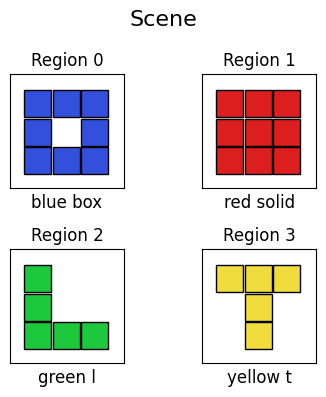

In [4]:
# 初始化
rsa = RSAHelper(color_perturbation=0.2)

# 定义场景
rsa.visualize(["blue box", "red solid", "green l", "yellow t"])

# 1 归纳学习以及推理

In [5]:
rsa = RSAHelper(color_perturbation=0.1)

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)


### 1.1三次展示三个不同的物体，并说场上有1个物体，他们是abc样子的

训练 #1: ['red box'] → "1 abc"


f:\SCAI\RSA-RESEARCH\project\rsa_helper.py:453: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
f:\SCAI\RSA-RESEARCH\project\rsa_helper.py:453: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\APP\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\APP\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


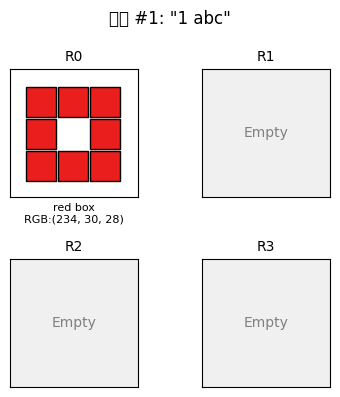

训练 #2: ['red l'] → "1 abc"


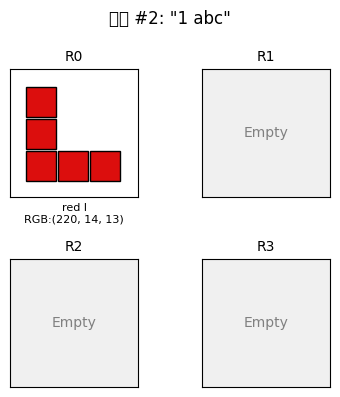

训练 #3: ['red t'] → "1 abc"


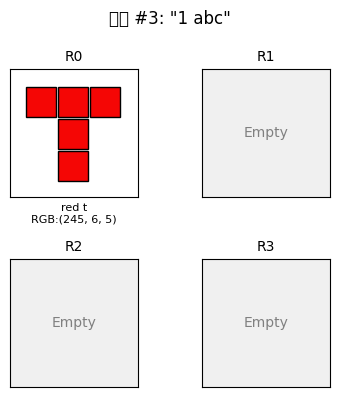

In [6]:

rsa.train(["red box", "", "", ""], "1 abc")
rsa.train(["red l", "", "", ""], "1 abc")
rsa.train(["red t", "", "", ""], "1 abc")

### 1.2 测试：
场上有三个非红色，但是形状之前见过的物体；还有一个是红色但是形状之前没有见过的物体。

询问者问：帮我找出场上那一个abc

模型需通过之前学习来进行推理。

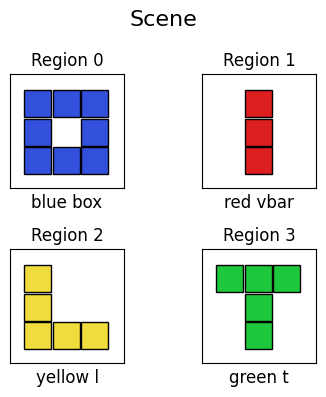

array([2.49305734e-05, 9.99753244e-01, 2.12832572e-04, 8.99323999e-06])

In [7]:
rsa.visualize(["blue box", "red vbar", "yellow l", "green t"])
probs = rsa.infer(["blue box", "red vbar", "yellow l", "green t"], "1 abc")
probs

### 1.3 歧义于错误归纳
如果几次学习中的示例并不典范，存在多个共同特性，会怎么样。
将会给出一个红色box形状和一个红色solid形状，同时提供描述让模型学习。

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.3)
训练 #1: ['red box'] → "1 cba"


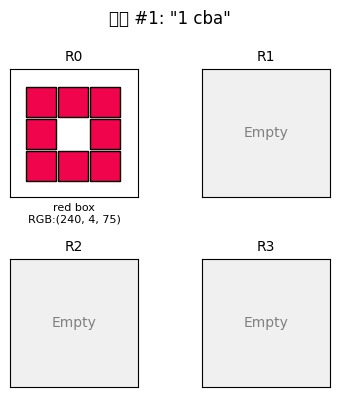

训练 #2: ['red solid'] → "1 cba"


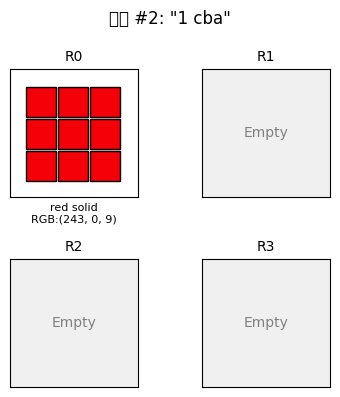

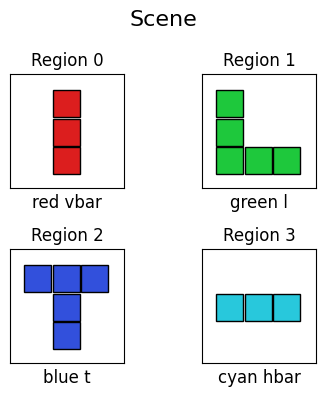

array([2.03952492e-01, 6.96717510e-01, 9.93207328e-02, 9.26533088e-06])

In [8]:
rsa = RSAHelper(color_perturbation=0.2, shape_sigma=0.3)
rsa.train(["red box", "", "", ""], "1 cba")
rsa.train(["red solid", "", "", ""], "1 cba")

rsa.visualize(["red vbar", "green l", "blue t", "cyan hbar"])
probs = rsa.infer(["red vbar", "green l", "blue t", "cyan hbar"], "1 cba")
probs

### 1.4 多示例后，可以修复错误概念
不重置模型，接着展示多两个“红色”案例。希望abc这个概念能正确校正。

训练 #3: ['red t_180'] → "1 cba"


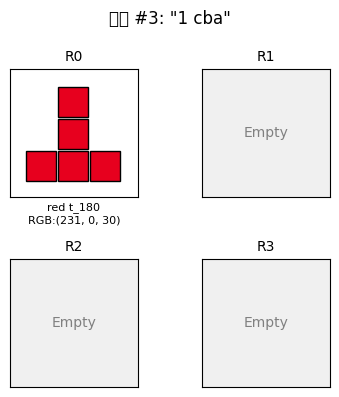

训练 #4: ['red t_270'] → "1 cba"


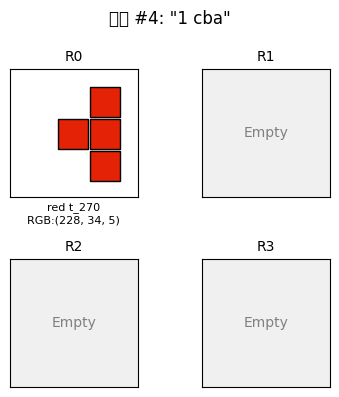

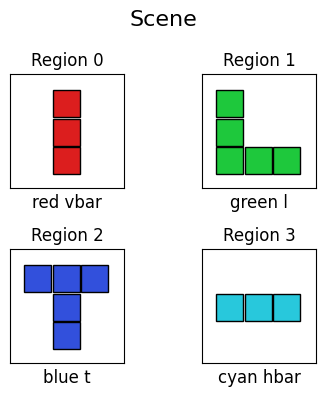

array([9.99999869e-01, 1.84436774e-08, 1.12663979e-07, 5.32457594e-11])

In [9]:
rsa.train(["red t_180", "", "", ""], "1 cba")
rsa.train(["red t_270", "", "", ""], "1 cba")

rsa.visualize(["red vbar", "green l", "blue t", "cyan hbar"])
probs = rsa.infer(["red vbar", "green l", "blue t", "cyan hbar"], "1 cba")
probs

# 2. RSA

模拟RSA经典场景。当场景上有三个人：一个普通人，一个戴眼镜的人，一个戴眼镜和帽子的人。如果另一个人说：戴眼镜那个人是我的朋友；应当能推断出只戴眼镜的人是目标。

通过三次红色图案训练，和三次实心图案训练，让当模型学会“红色”这个颜色概念，和“实心”这个形状概念。
然后，展示一个场景有三个物体，其中两个是红色的，其中一个红色物体是实心的。
提问：请帮我找出场上那一个“红色的”

In [10]:
rsa = RSAHelper(color_perturbation=0.2)

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)


训练 #1: ['red l'] → "1 abc"


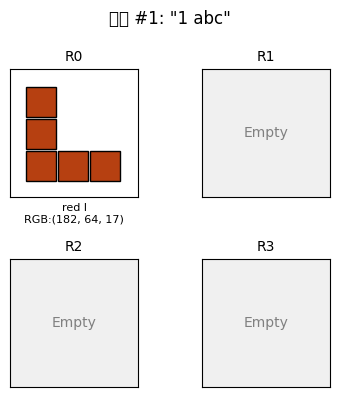

训练 #2: ['red hbar'] → "1 abc"


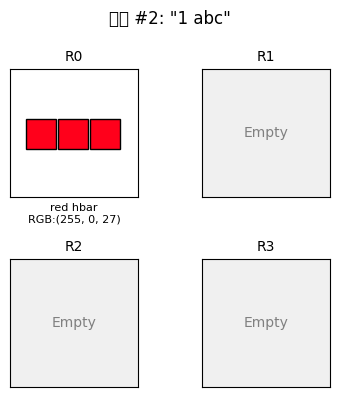

训练 #3: ['red t'] → "1 abc"


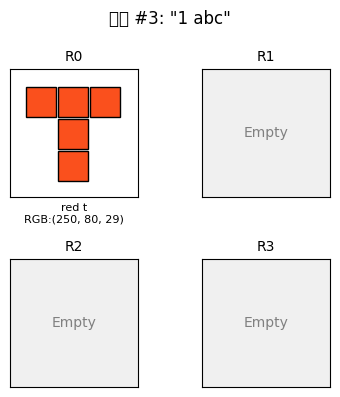

训练 #4: ['red solid'] → "1 s"


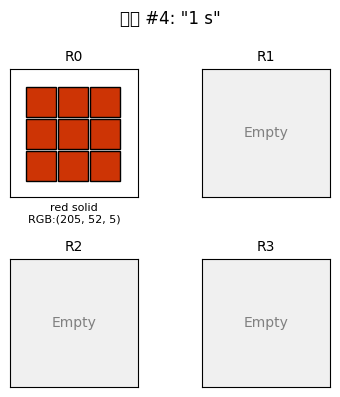

训练 #5: ['blue solid'] → "1 s"


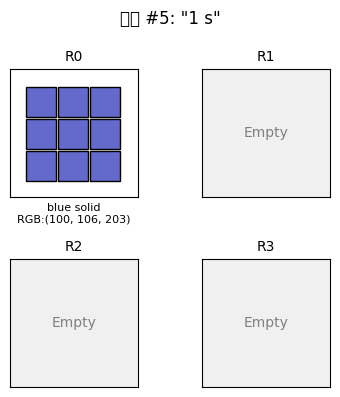

训练 #6: ['green solid'] → "1 s"


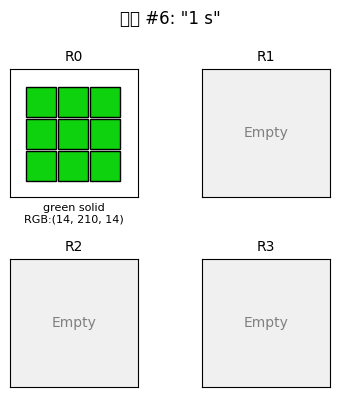

In [11]:
rsa.train(["red l", "", "", ""], "1 abc")
rsa.train(["red hbar", "", "", ""], "1 abc")
rsa.train(["red t", "", "", ""], "1 abc")
rsa.train(["red solid", "", "", ""], "1 s")
rsa.train(["blue solid", "", "", ""], "1 s")
rsa.train(["green solid", "", "", ""], "1 s")

三个物体，其中两个是红色的，其中一个红色物体时实心的。

提问：请帮我找出场上那一个“红色的”

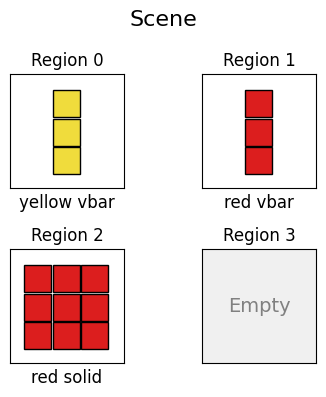

array([7.15150061e-06, 9.97407104e-01, 2.58574413e-03, 0.00000000e+00])

In [12]:
rsa.visualize(["yellow vbar", "red vbar", "red solid", ""])
probs = rsa.infer(["yellow vbar", "red vbar", "red solid", ""], "1 abc")
probs

# 3. 组合语义解析

模拟多物体指代的RSA问题。

如果场景上有四个人：一个普通人，一个戴眼镜的，一个戴帽子的，一个又戴眼镜又戴帽子的。

提问：帮我找出场上那一个戴眼镜的和那一个戴帽子的。

期望：只戴眼镜和只戴帽子的，要不然会说两个戴眼镜的或两个戴帽子的，或者是听到一个新词。

实验：
模型将被展示两次“蓝色”物体和两次“实心”物体进行概念学习。并被询问：帮我找出场上那一个“蓝色”的和那一个“实心”的。

概念表已重置
训练 #1: ['blue box'] → "1 blue"


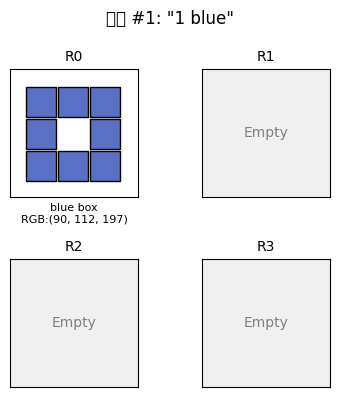

训练 #2: ['blue l'] → "1 blue"


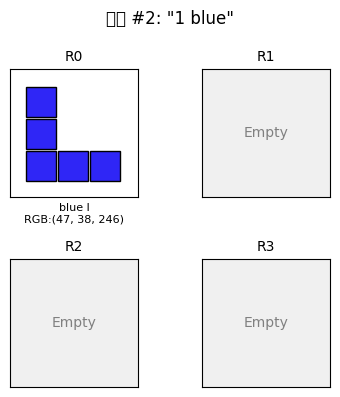

训练 #3: ['red solid'] → "1 solid"


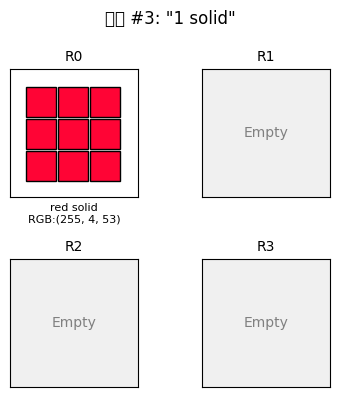

训练 #4: ['green solid'] → "1 solid"


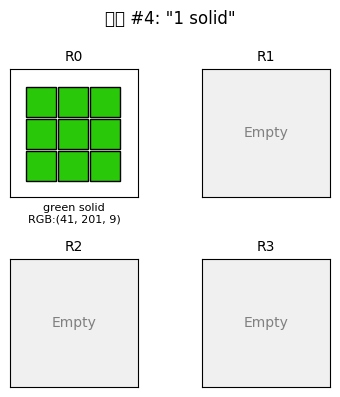

In [13]:
rsa.reset()
rsa.train(["blue box", "", "", ""], "1 blue")
rsa.train(["blue l", "", "", ""], "1 blue")
rsa.train(["red solid", "", "", ""], "1 solid")
rsa.train(["green solid", "", "", ""], "1 solid")

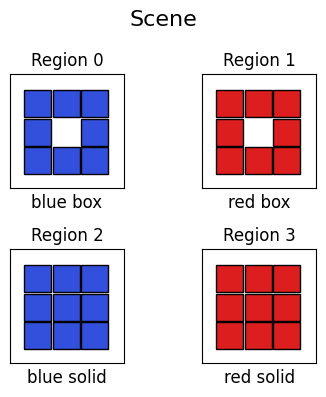

array([9.97406765e-01, 2.10205410e-11, 2.59323479e-03, 1.00000000e+00])

In [14]:
rsa.visualize(["blue box", "red box", "blue solid", "red solid"])
probs = rsa.infer(["blue box", "red box", "blue solid", "red solid"], "1 blue, 1 solid")
probs

# 4. 不确定性学习（RSA和归纳学习融合）
如果一个人本身具有红色这个概念，但没有蓝色这个概念的时候。如果场上有一个红色的，一个蓝色的物体。提问者说“给我蓝色那个物体”，人可以推断出“蓝色”指代的物体，并且学习这个新概念，并且之后会巩固这个概念。

实验：

初始模型。展示三个场景，每个场景只有一个红色物体并说”一个红色”。然后再展示三个场景，每个场景有一个红色和一个蓝色，并且说“一个蓝色”。期望之后模型具有区别蓝色的能力。

概念表已重置
训练 #1: ['red box'] → "1 red"


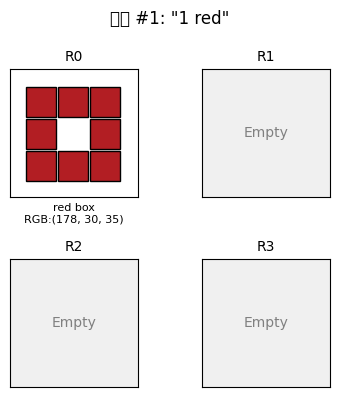

训练 #2: ['red l'] → "1 red"


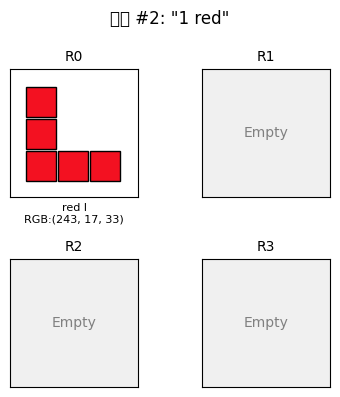

训练 #3: ['red t'] → "1 red"


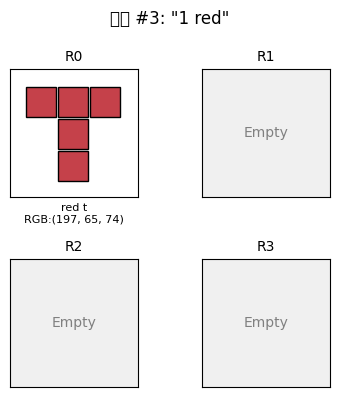

训练 #4: ['red t_180', 'blue box'] → "1 qwe"


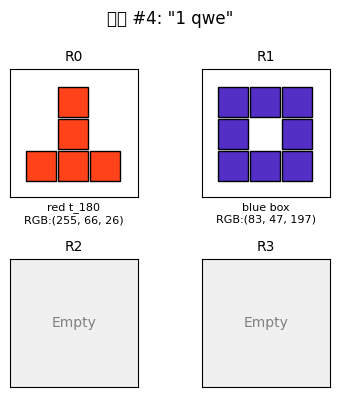

训练 #5: ['red solid', 'blue l_90'] → "1 qwe"


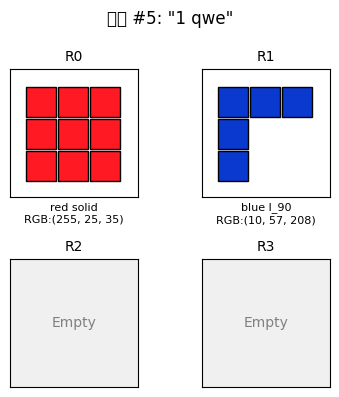

训练 #6: ['red l_90', 'blue solid'] → "1 qwe"


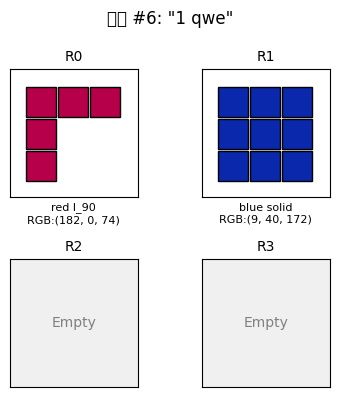

In [15]:
rsa.reset()
rsa.train(["red box", "", "", ""], "1 red")
rsa.train(["red l", "", "", ""], "1 red")
rsa.train(["red t", "", "", ""], "1 red")


rsa.train(["red t_180", "blue box", "", ""], "1 qwe")
rsa.train(["red solid", "blue l_90", "", ""], "1 qwe")
rsa.train(["red l_90", "blue solid", "", ""], "1 qwe")


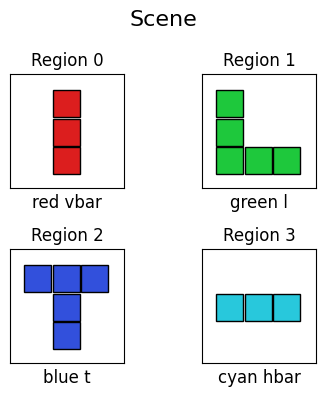

array([2.02373780e-03, 2.33083774e-10, 9.97976258e-01, 4.10290204e-09])

In [16]:
rsa.visualize(["red vbar", "green l", "blue t", "cyan hbar"])
probs = rsa.infer(["red vbar", "green l", "blue t", "cyan hbar"], "1 qwe")
probs

# 5. 颜色相似

人类具有色彩感知能力，比如粉色，橙色与红色很接近。当人类不知道粉色或者是橙色的概念的时候，是会用相近的颜色表示。

实验：模型将学习两个红色物品的场景，学习红色概念。实验场景下，没有红色的物体，但是有橙色，青色，蓝色，绿色。然后被询问：哪个是红色的那个。

概念表已重置
训练 #1: ['red box'] → "1 abc"


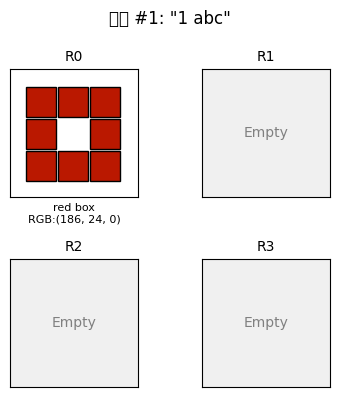

训练 #2: ['red solid'] → "1 abc"


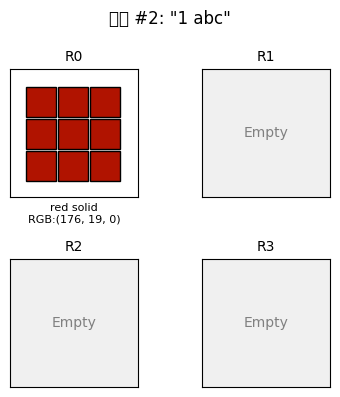

In [17]:
rsa.reset()

rsa.train(["red box", "", "", ""], "1 abc")
rsa.train(["red solid", "", "", ""], "1 abc")

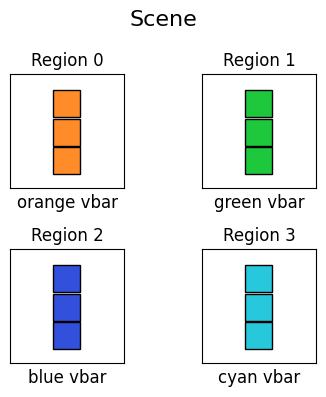

array([9.90050631e-01, 1.99200745e-04, 9.26855374e-03, 4.81614338e-04])

In [18]:
rsa.visualize(["orange vbar", "green vbar", "blue vbar", "cyan vbar"])
probs = rsa.infer(["orange vbar", "green vbar", "blue vbar", "cyan vbar"], "1 abc")
probs

# 6 Zero-Shot

如果人知道红色这个概念，以及黄色这个概念。并且从书本上经过大量阅读，习得”橙色“这个描述是描述一个物体类似”红色“又类似”黄色“。当提供几个物体（橙色，红色，黄色，蓝色）时候，如果提问：哪个是“橙色”，人应当能知道哪个可能是。

实验1： 书本上词汇描述通过”word2vec“来模拟。模型将被 1.展示三个场景，每个场景一个红色物体并告知”红色“。2.展示三个场景，每个场景一个黄色物体并告知”黄色“。3.展示三个场景，每个场景一个蓝色物体并告知”蓝色“ （学习红黄蓝概念）

然后将展示四个物体，分别是橙、红、绿、紫。问模型，哪个是橙色。

实验2： 书本上词汇描述通过”word2vec“来模拟。模型将被 1.展示三个场景，每个场景一个竖直条状物体并告知”垂直“。2.展示三个场景，每个场景一个水平条状物体并告知”水平“。3.展示三个场景，每个场景一个方框物体并告知”box“

然后展示四个物体，分别是cross，z形，斜线，角落形状，并询问哪个是”cross“

实验3： 类似实验2，不过这次是展示cross，z形，斜线，角落形状，并询问哪个是”斜线“（不过失败了可能是训练场景的任意概念组合不可能得到斜线。即有点类似只能推断出能想象的内容，想象不到的内容是难推断出来的。）

### 6.1 颜色

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)
训练 #1: ['red box'] → "1 red"
训练 #2: ['red T'] → "1 red"
训练 #3: ['red hbar'] → "1 red"
训练 #4: ['yellow box'] → "1 yellow"
训练 #5: ['yellow T'] → "1 yellow"
训练 #6: ['yellow hbar'] → "1 yellow"
训练 #7: ['blue box'] → "1 blue"
训练 #8: ['blue T'] → "1 blue"
训练 #9: ['blue hbar'] → "1 blue"
['red', 'yellow', 'blue']
[synthesize_concept] 合成 'orange':
  - 27.8% from red
  - 36.1% from yellow
  - 36.1% from blue
[synthesize_concept] 成功创建 'orange' (kappa=0.1)


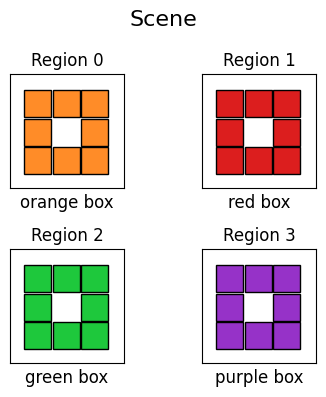

[0.52333606 0.45026964 0.00109512 0.02529918]


In [19]:

import numpy as np
from rsa_helper import RSAHelper
rsa = RSAHelper(color_perturbation=0)
# ========== Step 1: 训练基础概念 (视觉接地) ==========
rsa.train(["red box", "", "", ""], "1 red", show=False)
rsa.train(["red T", "", "", ""], "1 red", show=False)
rsa.train(["red hbar", "", "", ""], "1 red", show=False)

rsa.train(["yellow box", "", "", ""], "1 yellow", show=False)
rsa.train(["yellow T", "", "", ""], "1 yellow", show=False)
rsa.train(["yellow hbar", "", "", ""], "1 yellow", show=False)

rsa.train(["blue box", "", "", ""], "1 blue", show=False)
rsa.train(["blue T", "", "", ""], "1 blue", show=False)
rsa.train(["blue hbar", "", "", ""], "1 blue", show=False)
# ========== Step 2: 注入语义向量 ==========
# 只有已学过的概念才能注入 embedding
vec_red    =  wv['red']
vec_yellow = wv['yellow']
vec_blue   = wv['blue']

rsa.add_embedding("red", vec_red)      # 返回 True
rsa.add_embedding("yellow", vec_yellow)
rsa.add_embedding("blue", vec_blue)
# 查看已注入的概念
print(rsa.grounded_concepts())  # ['red', 'yellow', 'blue']
# ========== Step 3: 零样本合成新概念 ==========
# orange 语义上是 red + yellow 的混合
vec_orange = wv['orange']
rsa.synthesize_concept("orange", vec_orange, temp=0.1)

scene = ["orange box", "red box", "green box", "purple box"]
probs = rsa.infer(scene, "1 orange")
rsa.visualize(["orange box", "red box", "green box", "purple box"])
print(probs)

### 6.2 cross

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)
训练 #1: ['red vbar'] → "1 vbar"
训练 #2: ['blue vbar'] → "1 vbar"
训练 #3: ['pink vbar'] → "1 vbar"
训练 #4: ['green vbar'] → "1 vbar"
训练 #5: ['red hbar'] → "1 hbar"
训练 #6: ['blue hbar'] → "1 hbar"
训练 #7: ['pink hbar'] → "1 hbar"
训练 #8: ['green hbar'] → "1 hbar"
训练 #9: ['red box'] → "1 rectangle"
训练 #10: ['blue box'] → "1 rectangle"
训练 #11: ['pink box'] → "1 rectangle"
训练 #12: ['green box'] → "1 rectangle"
['vbar', 'hbar', 'rectangle']
[synthesize_concept] 合成 'cross':
  - 32.6% from vbar
  - 49.6% from hbar
  - 17.8% from rectangle
[synthesize_concept] 成功创建 'cross' (kappa=0.1)


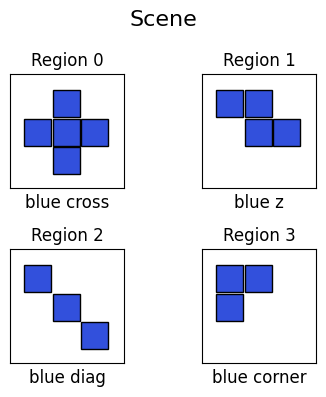

[9.99997611e-01 2.38696859e-06 1.79715559e-09 6.15521613e-10]


In [20]:
import numpy as np
from rsa_helper import RSAHelper
rsa = RSAHelper(color_perturbation=0.2)
# ========== Step 1: 训练基础概念 (视觉接地) ==========
rsa.train(["red vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["blue vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["pink vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["green vbar", "", "", ""], "1 vbar", show=False)

rsa.train(["red hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["blue hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["pink hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["green hbar", "", "", ""], "1 hbar", show=False)

rsa.train(["red box", "", "", ""], "1 rectangle", show=False)
rsa.train(["blue box", "", "", ""], "1 rectangle", show=False)
rsa.train(["pink box", "", "", ""], "1 rectangle", show=False)
rsa.train(["green box", "", "", ""], "1 rectangle", show=False)
# ========== Step 2: 注入语义向量 ==========
# 只有已学过的概念才能注入 embedding
vec_vertical    =  wv['vertical']
vec_horizontal = wv['horizontal']
vec_rectangle = wv['rectangle']
rsa.add_embedding("hbar", vec_horizontal)      # 返回 True
rsa.add_embedding("vbar", vec_vertical)
rsa.add_embedding("rectangle", vec_rectangle)
# 查看已注入的概念
print(rsa.grounded_concepts())  # ['red', 'yellow', 'blue']
# ========== Step 3: 零样本合成新概念 ==========
# orange 语义上是 red + yellow 的混合
vec_cross = wv['cross']
rsa.synthesize_concept("cross", vec_cross, temp=0.1)

scene = ["blue cross", "blue z", "blue diag", "blue corner"]
probs = rsa.infer(scene, "1 cross")
rsa.visualize(["blue cross", "blue z", "blue diag", "blue corner"])
print(probs)

### 6.3 斜线

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.5)
训练 #1: ['red vbar'] → "1 vbar"
训练 #2: ['blue vbar'] → "1 vbar"
训练 #3: ['pink vbar'] → "1 vbar"
训练 #4: ['green vbar'] → "1 vbar"
训练 #5: ['red hbar'] → "1 hbar"
训练 #6: ['blue hbar'] → "1 hbar"
训练 #7: ['pink hbar'] → "1 hbar"
训练 #8: ['green hbar'] → "1 hbar"
训练 #9: ['red box'] → "1 rectangle"
训练 #10: ['blue box'] → "1 rectangle"
训练 #11: ['pink box'] → "1 rectangle"
训练 #12: ['green box'] → "1 rectangle"
['vbar', 'hbar', 'rectangle']
[synthesize_concept] 合成 'oblique':
  - 20.7% from vbar
  - 61.2% from hbar
  - 18.0% from rectangle
[synthesize_concept] 成功创建 'oblique' (kappa=0.1)


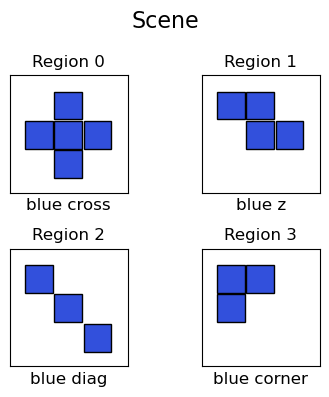

[9.99997291e-01 2.70507686e-06 3.31916457e-09 8.42853930e-10]


In [33]:
import numpy as np
from rsa_helper import RSAHelper
rsa = RSAHelper(color_perturbation=0.2)
# ========== Step 1: 训练基础概念 (视觉接地) ==========
rsa.train(["red vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["blue vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["pink vbar", "", "", ""], "1 vbar", show=False)
rsa.train(["green vbar", "", "", ""], "1 vbar", show=False)

rsa.train(["red hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["blue hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["pink hbar", "", "", ""], "1 hbar", show=False)
rsa.train(["green hbar", "", "", ""], "1 hbar", show=False)

rsa.train(["red box", "", "", ""], "1 rectangle", show=False)
rsa.train(["blue box", "", "", ""], "1 rectangle", show=False)
rsa.train(["pink box", "", "", ""], "1 rectangle", show=False)
rsa.train(["green box", "", "", ""], "1 rectangle", show=False)
# ========== Step 2: 注入语义向量 ==========
# 只有已学过的概念才能注入 embedding
vec_vertical    =  wv['vertical']
vec_horizontal = wv['horizontal']
vec_rectangle = wv['rectangle']
rsa.add_embedding("hbar", vec_horizontal)      # 返回 True
rsa.add_embedding("vbar", vec_vertical)
rsa.add_embedding("rectangle", vec_rectangle)
# 查看已注入的概念
print(rsa.grounded_concepts())  # ['red', 'yellow', 'blue']
# ========== Step 3: 零样本合成新概念 ==========
# orange 语义上是 red + yellow 的混合

vec_diagonal = wv['oblique']
rsa.synthesize_concept("oblique", vec_diagonal, temp=0.1)


scene = ["blue cross", "blue z", "blue diag", "blue corner"]
probs = rsa.infer(scene, "1 oblique")
rsa.visualize(["blue cross", "blue z", "blue diag", "blue corner"])
print(probs)

# 7.自我认知

人类学习到若干概念后，能够区分一个新的事物是否是属于旧有概念，还是一个具有新特性的物体。

实验：展示五次红色物体并告知“红色”。然后展示一个场景，第一个是红色的，第二个是蓝色的，然后问：你觉得第一个是什么，你觉得第二个是什么。模型应当回答“红色”和“不知道”

RSA Helper 初始化完成 (d=12, α=5.0, σ_shape=0.3)
训练 #1: ['red hbar'] → "1 red"


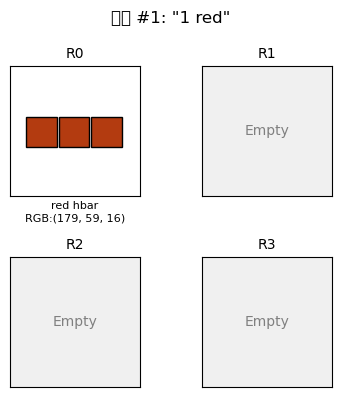

训练 #2: ['red l'] → "1 red"


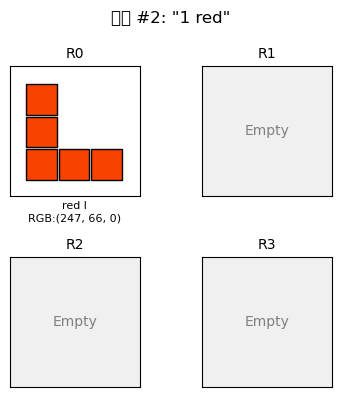

训练 #3: ['red vbar'] → "1 red"


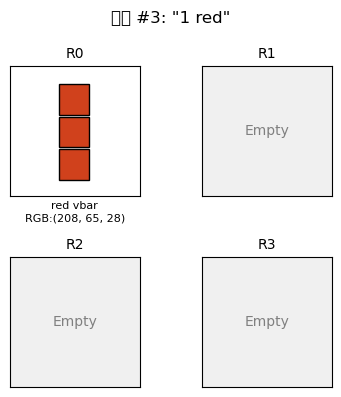

训练 #4: ['red T'] → "1 red"


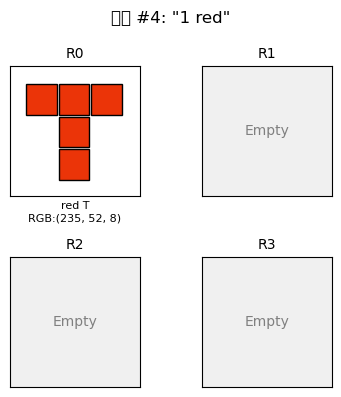

训练 #5: ['red l_90'] → "1 red"


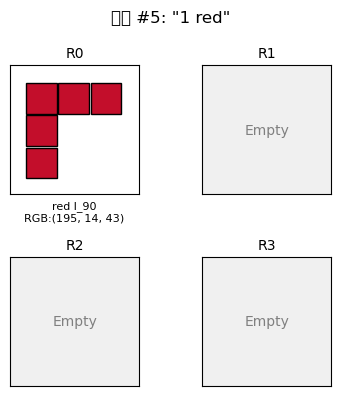

In [75]:
rsa = RSAHelper(color_perturbation=0.2, shape_sigma=0.3)
rsa.train(["red hbar", "", "", ""], "1 red")
rsa.train(["red l", "", "", ""], "1 red")
rsa.train(["red vbar", "", "", ""], "1 red")
rsa.train(["red T", "", "", ""], "1 red")
rsa.train(["red l_90", "", "", ""], "1 red")


[Ask] Position 0: KNOWN 'red' (Z=0.56, κ=6)
[Ask] Position 1: UNKNOWN (Z=-1.33, κ=6)
      Generated provisional: 'concept_431a6'


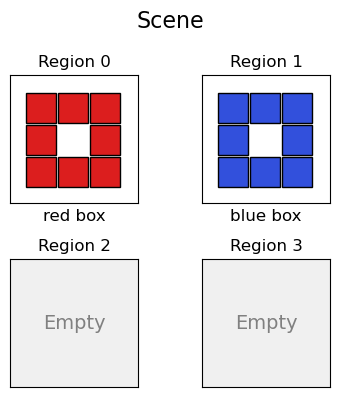

In [76]:
result = rsa.ask(["red box", "blue box", "", ""], position=0)
result = rsa.ask(["red box", "blue box", "", ""], position=1)
rsa.visualize(["red box", "blue box", "", ""])